momentos de una imagen

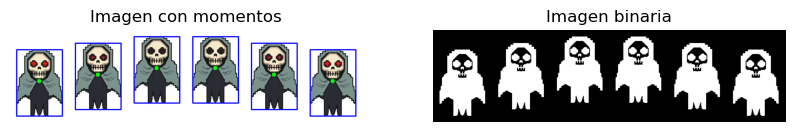

Contorno 1: Perímetro = 634.99, Área = 11972.00
Contorno 2: Perímetro = 634.99, Área = 11972.00
Contorno 3: Perímetro = 634.99, Área = 11972.00
Contorno 4: Perímetro = 634.99, Área = 11972.00
Contorno 5: Perímetro = 634.99, Área = 11972.00
Contorno 6: Perímetro = 634.99, Área = 11972.00
Contorno 1: Perímetro = 16.80 cm, Área = 8.38 cm²
Contorno 2: Perímetro = 16.80 cm, Área = 8.38 cm²
Contorno 3: Perímetro = 16.80 cm, Área = 8.38 cm²
Contorno 4: Perímetro = 16.80 cm, Área = 8.38 cm²
Contorno 5: Perímetro = 16.80 cm, Área = 8.38 cm²
Contorno 6: Perímetro = 16.80 cm, Área = 8.38 cm²


In [ ]:
#momentos de una imagen
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen= cv2.imread('img/contar.jpg')
gray= cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

ret, bin = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
contorno, jerarquia = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
perimetros = []
areas = []

for i in range(len(contorno)):
    cnt= contorno[i]
    M= cv2.moments(cnt)
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
    else:
        cx, cy = 0, 0
        
    area=cv2.contourArea(cnt)
    perimetro=cv2.arcLength(cnt, True)
    
    perimetros.append( perimetro )
    areas.append( area )
    cv2.circle(imagen, (cx, cy), 5, (0, 255, 0), -1)
    
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(imagen, (x, y), (x + w, y + h), (255, 0, 0), 2)
    
plt.figure(figsize=(10, 10))
plt.subplot(121)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title('Imagen con momentos')
plt.axis('off')

plt.subplot(122)
plt.imshow(bin, cmap='gray')
plt.title('Imagen binaria')
plt.axis('off')
plt.show()

for i, (perimetro, area) in enumerate(zip(perimetros, areas)):
    print(f"Contorno {i+1}: Perímetro = {perimetro:.2f}, Área = {area:.2f}")
    
# convertir las medidas a centimetros
conversion_factor = 0.0264583333  
perimetros_cm = [p * conversion_factor for p in perimetros]
areas_cm2 = [a * (conversion_factor ** 2) for a in areas]
for i, (perimetro_cm, area_cm2) in enumerate(zip(perimetros_cm, areas_cm2)):
    print(f"Contorno {i+1}: Perímetro = {perimetro_cm:.2f} cm, Área = {area_cm2:.2f} cm²")
    


detectar figuras en una imagen, calcular sus momentos y clasificarlas (aproximadamente) como circulo. cuadrado o triangulo en funcion de la forma de su contorno.

calcular los monentos de Hu (cv2.HuMoments). Aproximación  del contorno con cv2.approxPolyDP para contar vértices Clasificar la figura por vertices.

=== ANÁLISIS DE FIGURAS DETECTADAS ===



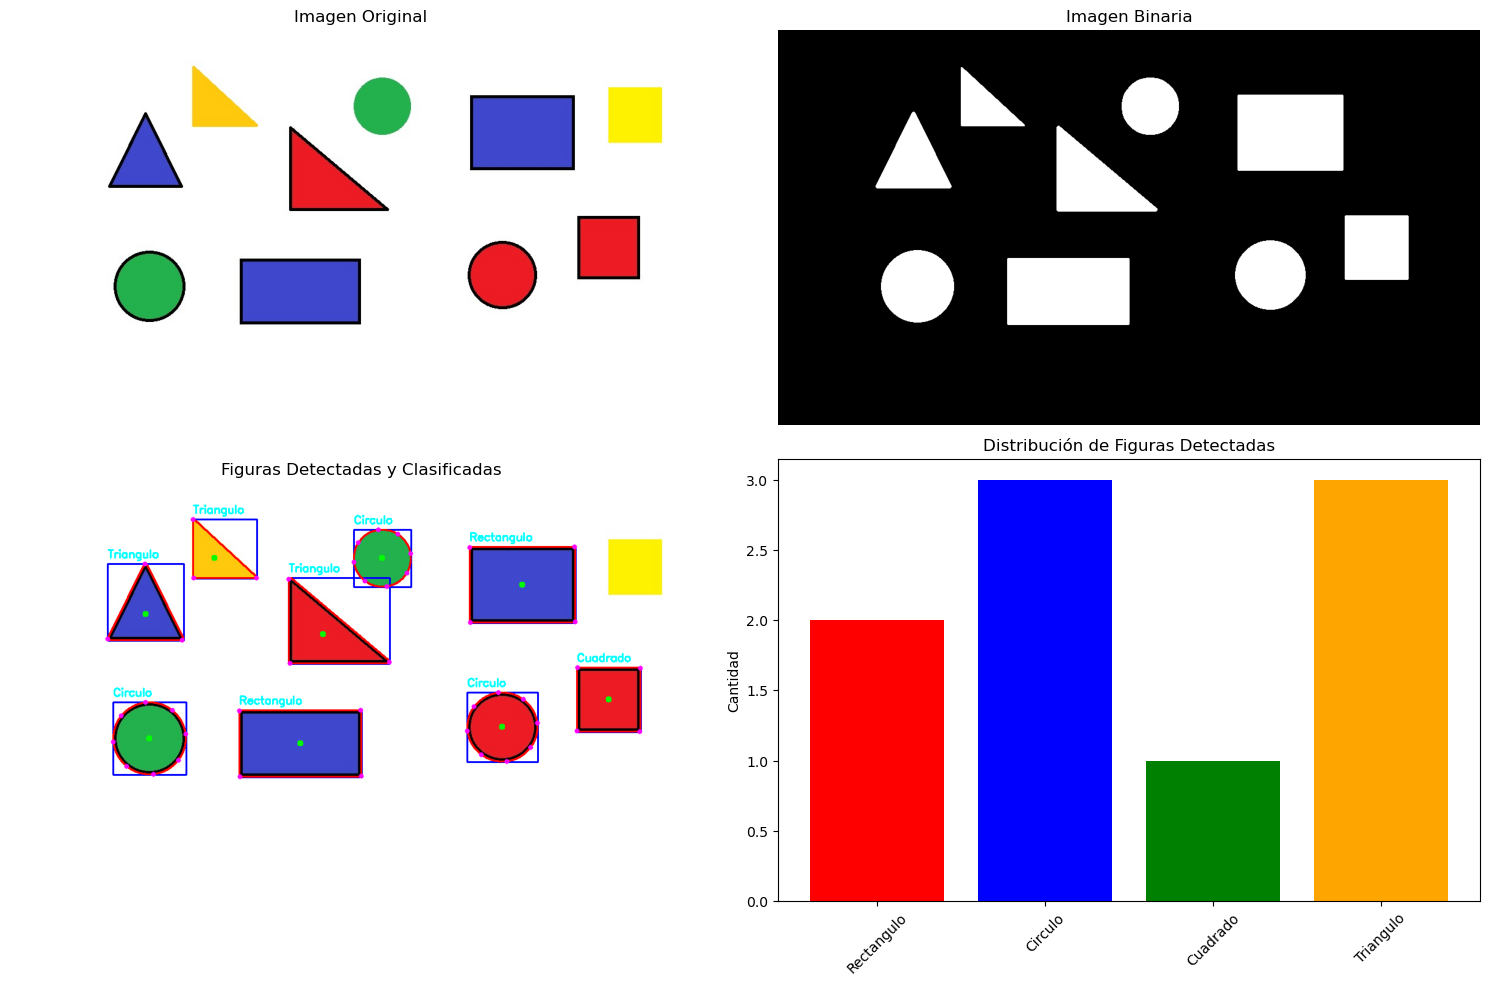

--- FIGURA 1 ---
Clasificación final: Rectangulo
Centroide: (476, 428)
Área: 21798.00 píxeles²
Perímetro: 615.66 píxeles
Vértices detectados: 4
Clasificación por vértices: Rectangulo
Clasificación por compacidad: Cuadrado/Rectangulo
Momentos de Hu (log):
  Hu1: 0.702668
  Hu2: 1.937354
  Hu3: 27.372684
  Hu4: 27.658847
  Hu5: 55.184920
  Hu6: 28.742827
  Hu7: -55.841547

--- FIGURA 2 ---
Clasificación final: Circulo
Centroide: (228, 420)
Área: 11004.00 píxeles²
Perímetro: 391.99 píxeles
Vértices detectados: 8
Clasificación por vértices: Circulo
Clasificación por compacidad: Circulo
Momentos de Hu (log):
  Hu1: 0.798147
  Hu2: 5.794999
  Hu3: 8.858919
  Hu4: 13.664193
  Hu5: 24.932095
  Hu6: 16.568480
  Hu7: 25.696062

--- FIGURA 3 ---
Clasificación final: Circulo
Centroide: (807, 401)
Área: 10178.00 píxeles²
Perímetro: 376.33 píxeles
Vértices detectados: 8
Clasificación por vértices: Circulo
Clasificación por compacidad: Circulo
Momentos de Hu (log):
  Hu1: 0.798094
  Hu2: 5.154307
  H

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def clasificar_figura_por_vertices(contorno):
    """Clasifica una figura basándose en el número de vértices después de aproximación poligonal"""
    # Calcular el perímetro para la aproximación
    perimeter = cv2.arcLength(contorno, True)
    # Aproximar el contorno a un polígono (epsilon = 2% del perímetro)
    epsilon = 0.02 * perimeter
    approx = cv2.approxPolyDP(contorno, epsilon, True)
    
    vertices = len(approx)
    
    if vertices == 3:
        return "Triangulo", vertices
    elif vertices == 4:
        # Verificar si es cuadrado o rectángulo
        x, y, w, h = cv2.boundingRect(contorno)
        aspect_ratio = float(w) / h
        if 0.9 <= aspect_ratio <= 1.1:
            return "Cuadrado", vertices
        else:
            return "Rectangulo", vertices
    elif vertices >= 8:
        return "Circulo", vertices
    else:
        return f"Poligono_{vertices}v", vertices

def clasificar_por_compacidad(area, perimetro):
    """Clasificación adicional basada en compacidad"""
    if perimetro == 0:
        return "Indefinido"
    
    compacidad = 4 * np.pi * area / (perimetro ** 2)
    
    if compacidad > 0.85:
        return "Circulo"
    elif 0.6 < compacidad <= 0.85:
        return "Cuadrado/Rectangulo"
    else:
        return "Triangulo/Poligono"

def analizar_momentos_hu(contorno):
    """Calcula y analiza los momentos de Hu"""
    moments = cv2.moments(contorno)
    hu_moments = cv2.HuMoments(moments)
    
    # Aplicar logaritmo para normalizar los valores
    hu_log = -np.sign(hu_moments) * np.log10(np.abs(hu_moments))
    
    return hu_log.flatten()

def procesar_imagen(ruta_imagen):
    """Función principal para procesar la imagen y detectar figuras"""
    
    # Cargar y procesar imagen
    imagen = cv2.imread(ruta_imagen)
    if imagen is None:
        print(f"Error: No se pudo cargar la imagen {ruta_imagen}")
        return
    
    imagen_original = imagen.copy()
    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    # Aplicar filtro gaussiano para reducir ruido
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Binarización
    ret, bin_img = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
    
    # Encontrar contornos
    contornos, jerarquia = cv2.findContours(bin_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Listas para almacenar resultados
    resultados = []
    
    print("=== ANÁLISIS DE FIGURAS DETECTADAS ===\n")
    
    for i, contorno in enumerate(contornos):
        # Filtrar contornos muy pequeños
        area = cv2.contourArea(contorno)
        if area < 100:  # Filtrar objetos muy pequeños
            continue
            
        # Calcular momentos regulares
        M = cv2.moments(contorno)
        
        # Calcular centroide
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
        else:
            cx, cy = 0, 0
        
        # Calcular área y perímetro
        perimetro = cv2.arcLength(contorno, True)
        
        # Clasificar por vértices
        forma_vertices, num_vertices = clasificar_figura_por_vertices(contorno)
        
        # Clasificar por compacidad
        forma_compacidad = clasificar_por_compacidad(area, perimetro)
        
        # Calcular momentos de Hu
        momentos_hu = analizar_momentos_hu(contorno)
        
        # Determinar clasificación final
        if "Circulo" in forma_vertices or "Circulo" in forma_compacidad:
            clasificacion_final = "Circulo"
        elif "Triangulo" in forma_vertices or "Triangulo" in forma_compacidad:
            clasificacion_final = "Triangulo"
        elif "Cuadrado" in forma_vertices or "Rectangulo" in forma_vertices:
            clasificacion_final = forma_vertices
        else:
            clasificacion_final = forma_vertices
        
        # Almacenar resultados
        resultado = {
            'id': i + 1,
            'centroide': (cx, cy),
            'area': area,
            'perimetro': perimetro,
            'vertices': num_vertices,
            'forma_vertices': forma_vertices,
            'forma_compacidad': forma_compacidad,
            'clasificacion_final': clasificacion_final,
            'momentos_hu': momentos_hu,
            'contorno': contorno
        }
        resultados.append(resultado)
        
        # Dibujar en la imagen
        # Centroide
        cv2.circle(imagen, (cx, cy), 5, (0, 255, 0), -1)
        
        # Bounding rectangle
        x, y, w, h = cv2.boundingRect(contorno)
        cv2.rectangle(imagen, (x, y), (x + w, y + h), (255, 0, 0), 2)
        
        # Contorno
        cv2.drawContours(imagen, [contorno], -1, (0, 0, 255), 2)
        
        # Etiqueta con clasificación
        cv2.putText(imagen, f"{clasificacion_final}", 
                   (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
        
        # Aproximación poligonal para visualizar vértices
        perimeter = cv2.arcLength(contorno, True)
        epsilon = 0.02 * perimeter
        approx = cv2.approxPolyDP(contorno, epsilon, True)
        
        for punto in approx:
            cv2.circle(imagen, tuple(punto[0]), 4, (255, 0, 255), -1)
    
    # Mostrar resultados
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(imagen_original, cv2.COLOR_BGR2RGB))
    plt.title('Imagen Original')
    plt.axis('off')
    
    plt.subplot(2, 2, 2)
    plt.imshow(bin_img, cmap='gray')
    plt.title('Imagen Binaria')
    plt.axis('off')
    
    plt.subplot(2, 2, 3)
    plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.title('Figuras Detectadas y Clasificadas')
    plt.axis('off')
    
    # Gráfico de barras con clasificaciones
    plt.subplot(2, 2, 4)
    clasificaciones = [r['clasificacion_final'] for r in resultados]
    from collections import Counter
    contador = Counter(clasificaciones)
    
    plt.bar(contador.keys(), contador.values(), color=['red', 'blue', 'green', 'orange', 'purple'])
    plt.title('Distribución de Figuras Detectadas')
    plt.ylabel('Cantidad')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Imprimir resultados detallados
    for resultado in resultados:
        print(f"--- FIGURA {resultado['id']} ---")
        print(f"Clasificación final: {resultado['clasificacion_final']}")
        print(f"Centroide: {resultado['centroide']}")
        print(f"Área: {resultado['area']:.2f} píxeles²")
        print(f"Perímetro: {resultado['perimetro']:.2f} píxeles")
        print(f"Vértices detectados: {resultado['vertices']}")
        print(f"Clasificación por vértices: {resultado['forma_vertices']}")
        print(f"Clasificación por compacidad: {resultado['forma_compacidad']}")
        print(f"Momentos de Hu (log):")
        for j, hu in enumerate(resultado['momentos_hu']):
            print(f"  Hu{j+1}: {hu:.6f}")
        print()
    
    # Factor de conversión (ajustar según la escala de tu imagen)
    conversion_factor = 0.0264583333
    print("=== MEDIDAS EN CENTÍMETROS ===")
    for resultado in resultados:
        area_cm2 = resultado['area'] * (conversion_factor ** 2)
        perimetro_cm = resultado['perimetro'] * conversion_factor
        print(f"Figura {resultado['id']} ({resultado['clasificacion_final']}): "
              f"Área = {area_cm2:.2f} cm², Perímetro = {perimetro_cm:.2f} cm")
    
    return resultados

# Función para comparar formas usando momentos de Hu
def comparar_formas(momentos_hu1, momentos_hu2):
    """Compara dos conjuntos de momentos de Hu"""
    diferencia = np.sum(np.abs(momentos_hu1 - momentos_hu2))
    return diferencia

# Ejemplo de uso
if __name__ == "__main__":
    # Cambiar por la ruta de tu imagen
    ruta_imagen = 'img/figuras02.jpg'
    
    try:
        resultados = procesar_imagen(ruta_imagen)
        
        # Ejemplo de comparación entre formas
        if len(resultados) >= 2:
            print("\n=== COMPARACIÓN DE FORMAS (Momentos de Hu) ===")
            for i in range(len(resultados)):
                for j in range(i+1, len(resultados)):
                    similitud = comparar_formas(resultados[i]['momentos_hu'], 
                                              resultados[j]['momentos_hu'])
                    print(f"Similitud entre Figura {i+1} y Figura {j+1}: {similitud:.6f}")
                    
    except Exception as e:
        print(f"Error al procesar la imagen: {e}")
        print("Asegúrate de que la ruta de la imagen sea correcta.")